In [ ]:
# Task 1: Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
# Models
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
# Preprocessing
from sklearn.preprocessing import LabelEncoder, StandardScaler
# Train-test
from sklearn.model_selection import train_test_split
# Metrics
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
# SMOTE
from imblearn.over_sampling import SMOTE
# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

In [ ]:
# Task 2: Load Dataset

df = pd.read_csv("/content/telecom_churn_data (1).csv")
print(df.head())

   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV StreamingMovies        Contract Pape

In [ ]:
# Task 3: Check Dataset

print("Shape:", df.shape)

print("\nColumns:\n", df.columns)

print("\nData Types:\n")
print(df.dtypes)

print("\nSummary Statistics:\n")
print(df.describe())

Shape: (7043, 21)

Columns:
 Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

Data Types:

customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn           

In [ ]:
# Task 4: Missing Values

print("Missing values before:\n", df.isnull().sum())

# Drop missing (simple approach)
df.dropna(inplace=True)

print("\nMissing values after:\n", df.isnull().sum())

Missing values before:
 customerID          0
gender              5
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    2
PaymentMethod       0
MonthlyCharges      2
TotalCharges        5
Churn               0
dtype: int64

Missing values after:
 customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


In [ ]:
# Task 5: Remove Duplicates

print("Before:", df.shape)

df.drop_duplicates(inplace=True)

print("After:", df.shape)

Before: (7031, 21)
After: (7031, 21)


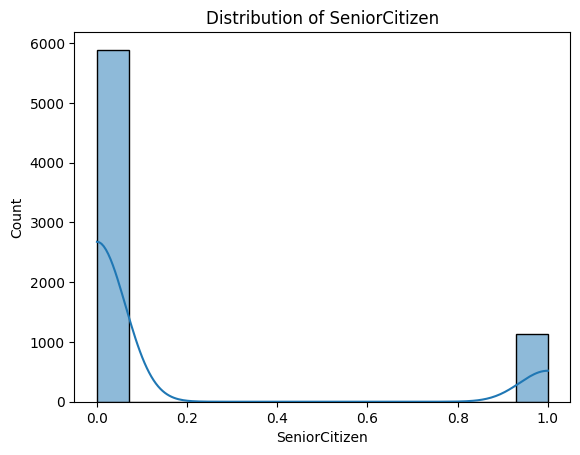

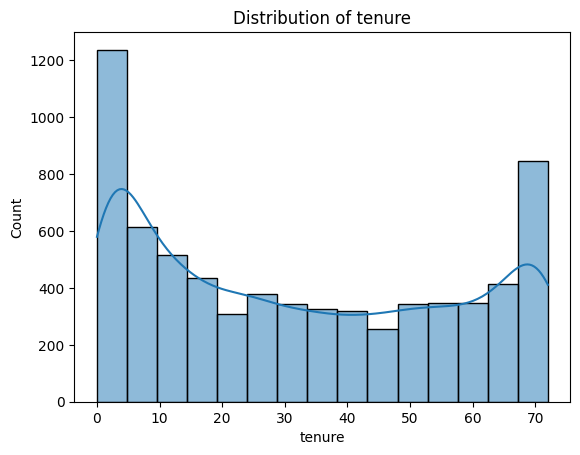

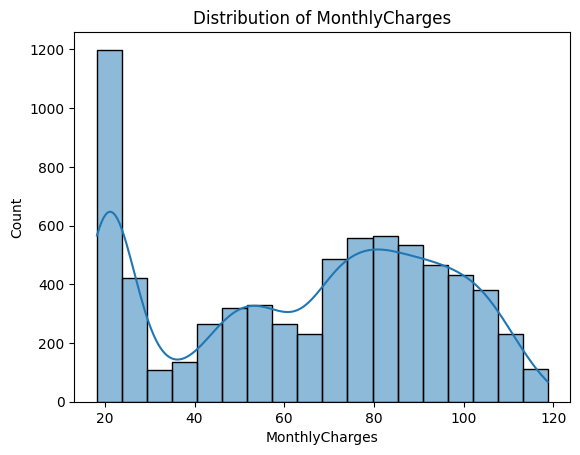

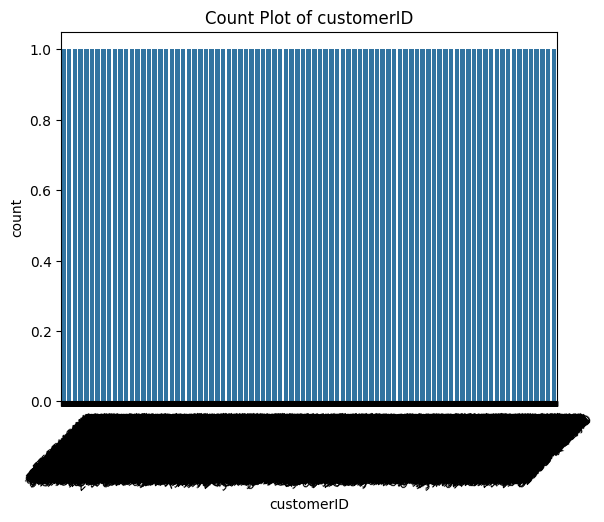

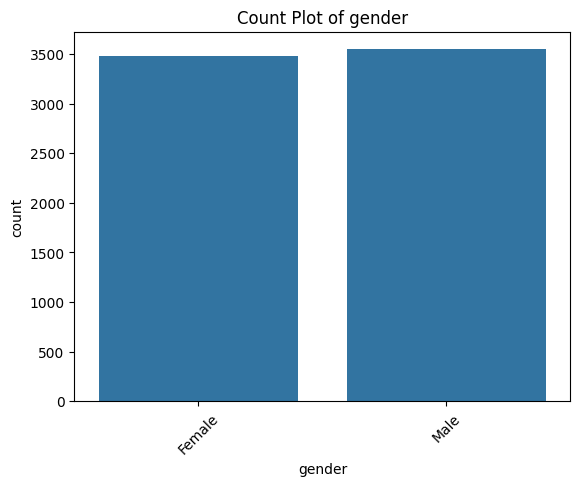

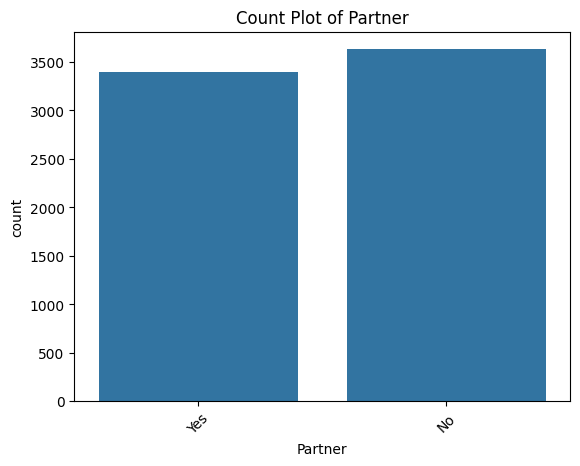

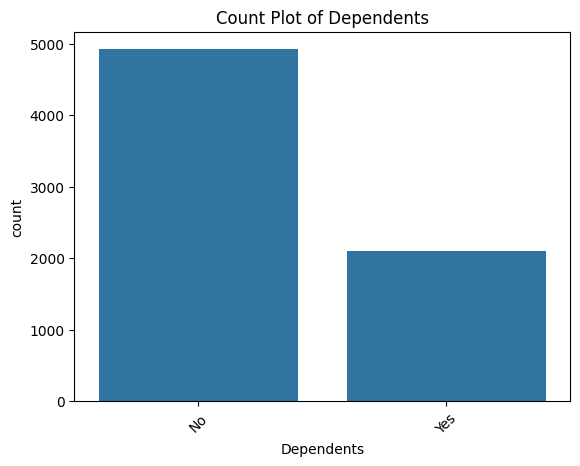

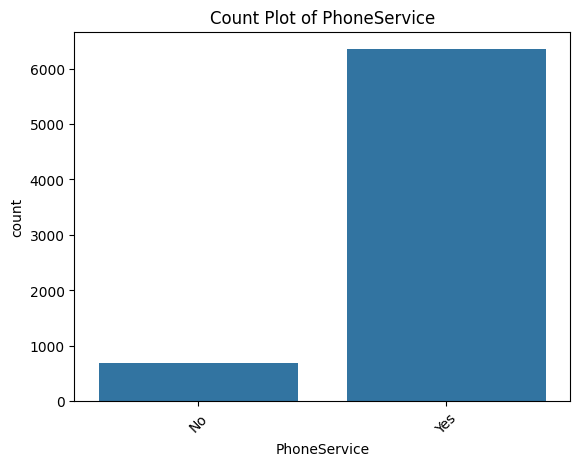

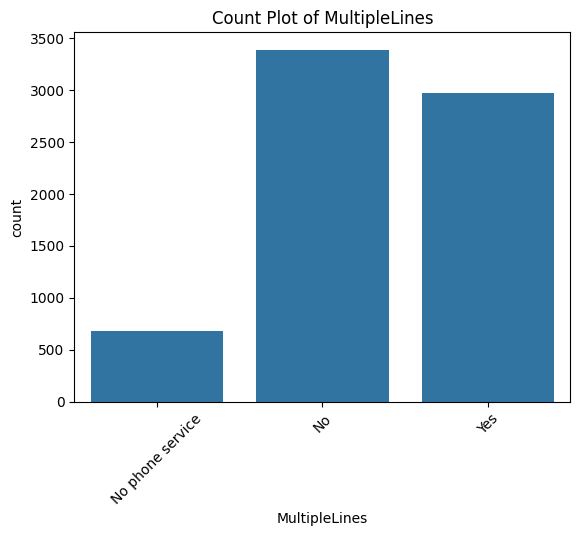

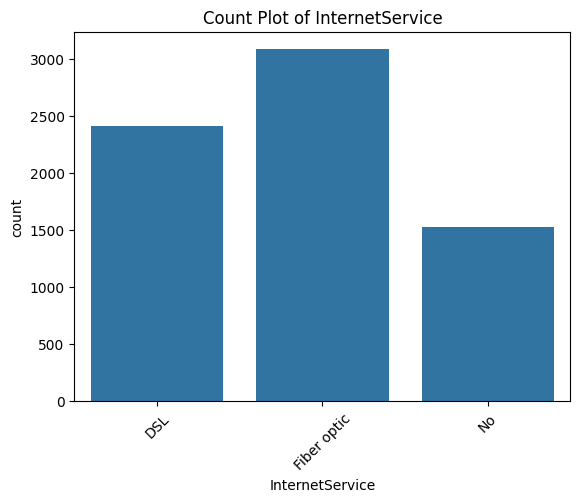

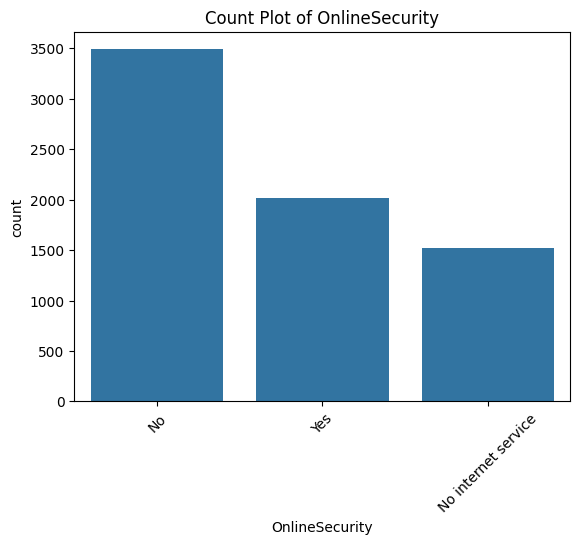

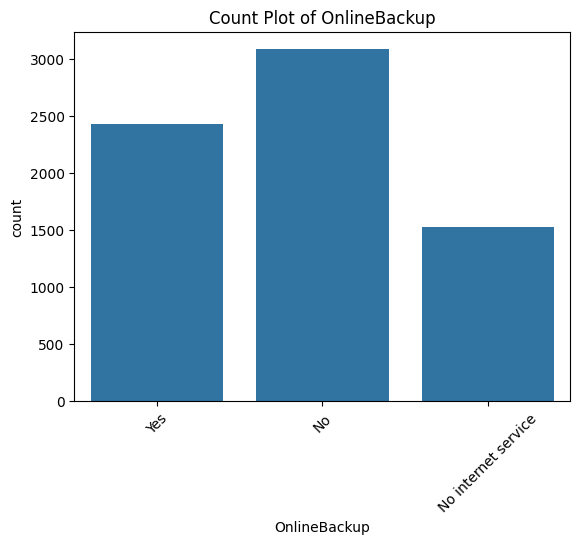

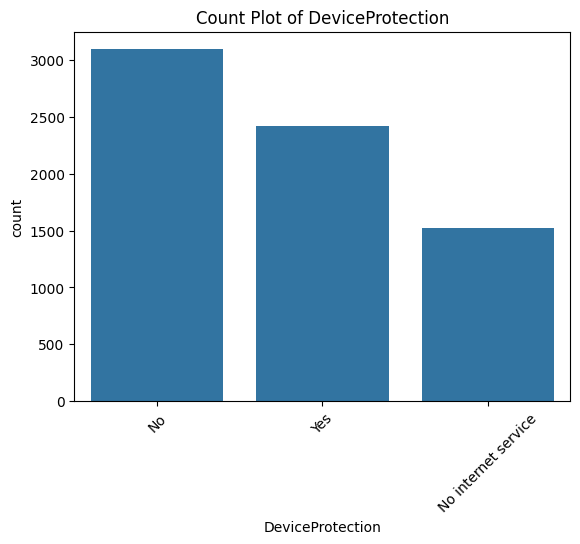

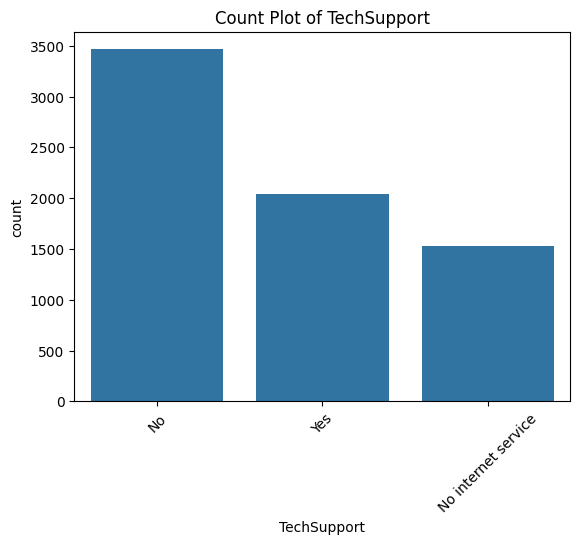

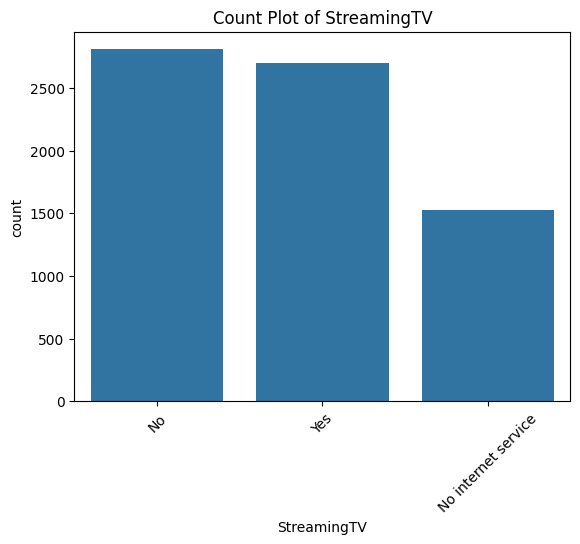

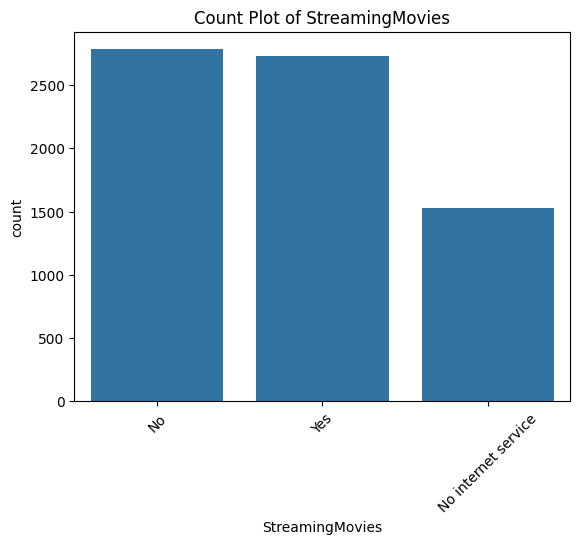

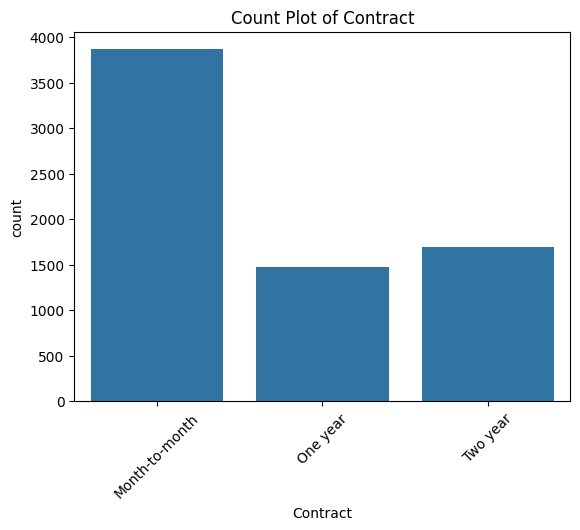

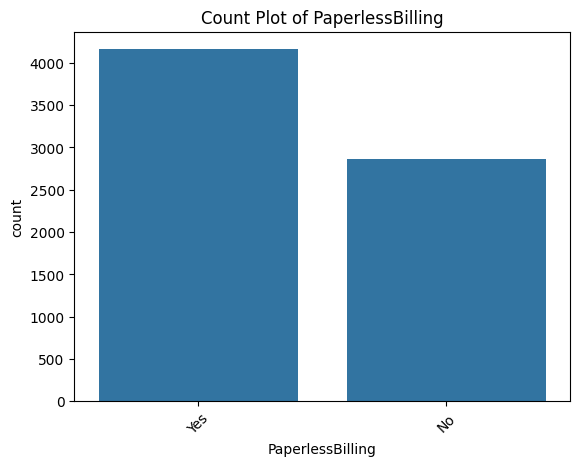

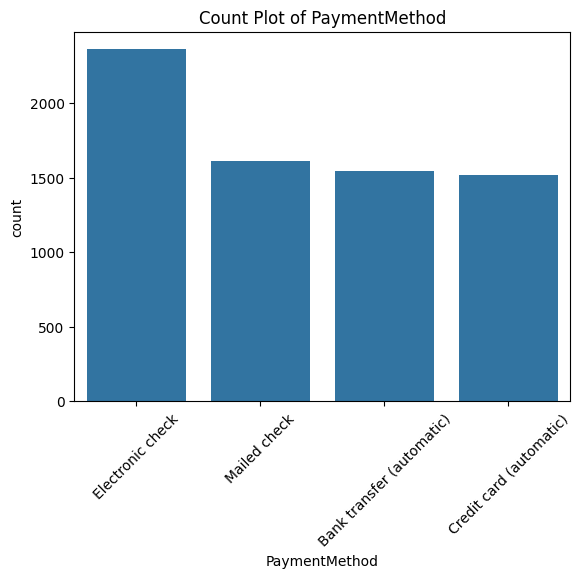

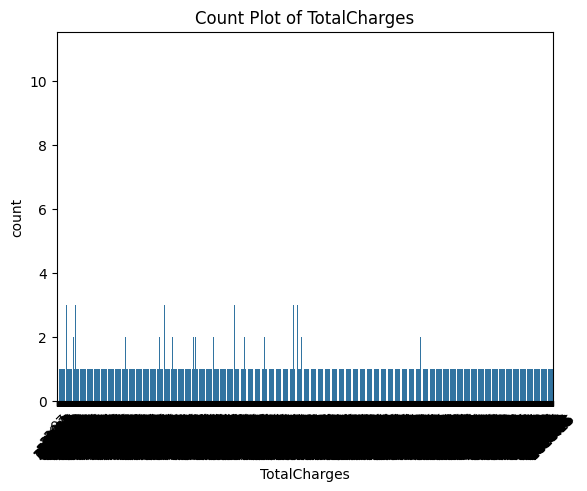

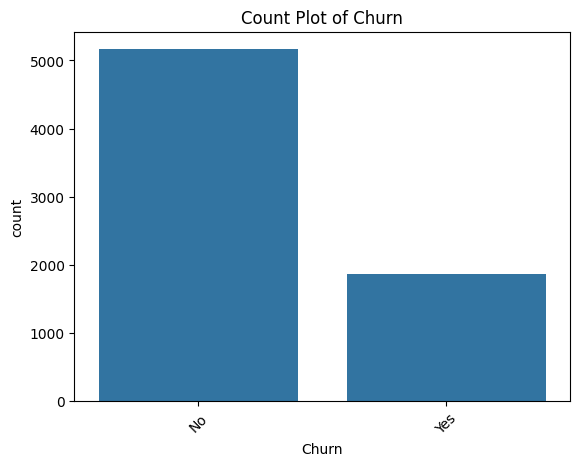

In [ ]:
# Task 6: Univariate Analysis

# Numerical columns
num_cols = df.select_dtypes(include=np.number).columns

for col in num_cols:
    plt.figure()
    sns.histplot(df[col], kde=True)
    plt.title(f"Distribution of {col}")
    plt.show()

# Categorical columns
cat_cols = df.select_dtypes(include='object').columns

for col in cat_cols:
    plt.figure()
    sns.countplot(x=df[col])
    plt.title(f"Count Plot of {col}")
    plt.xticks(rotation=45)
    plt.show()

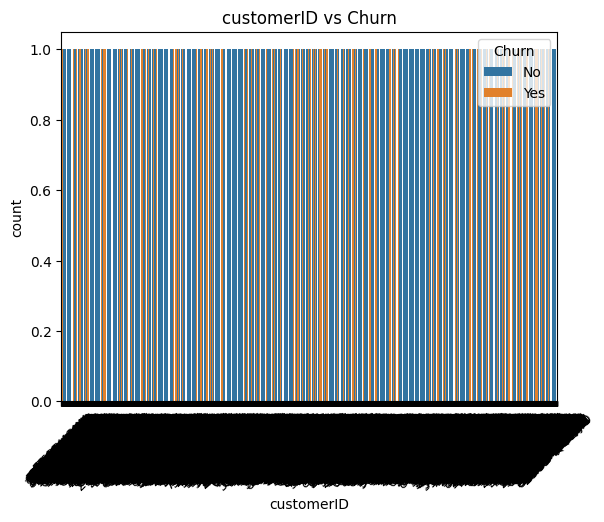

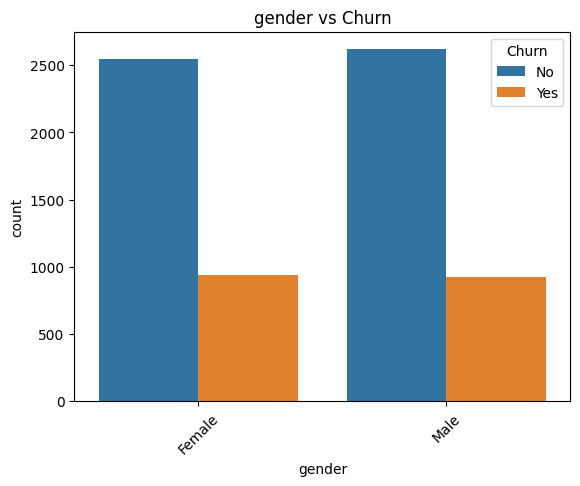

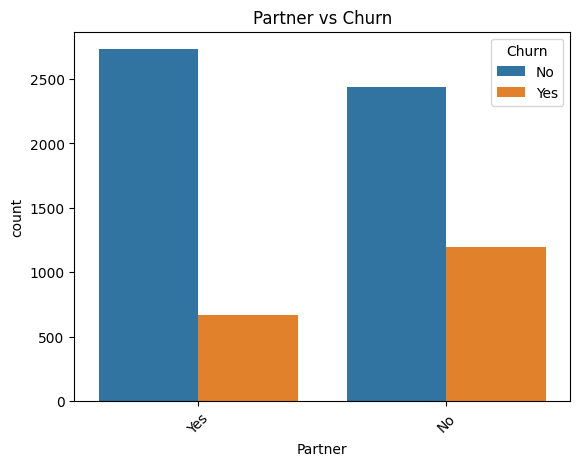

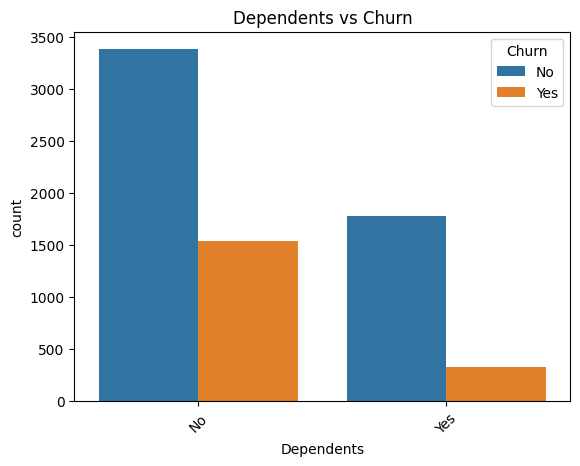

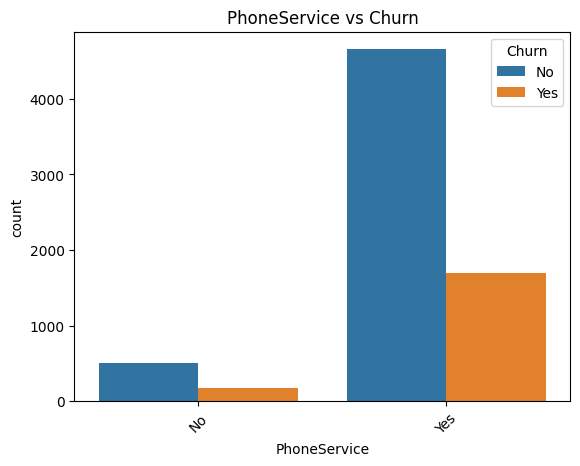

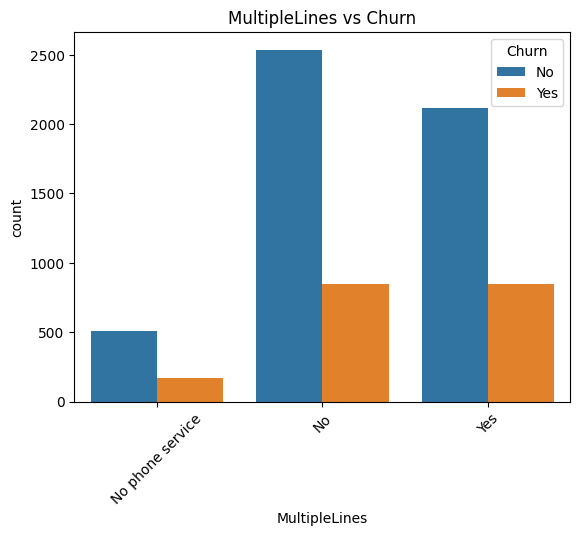

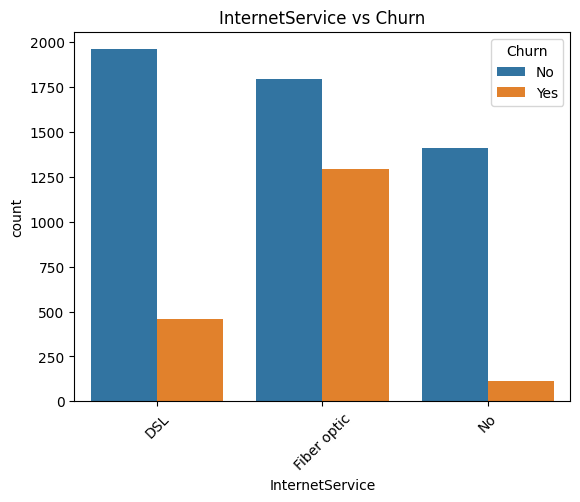

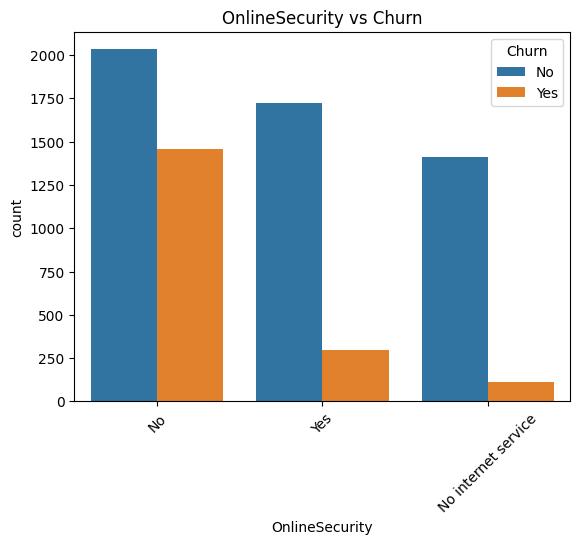

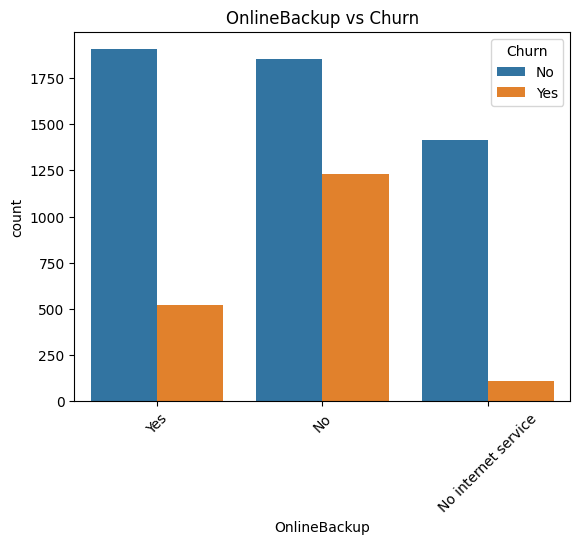

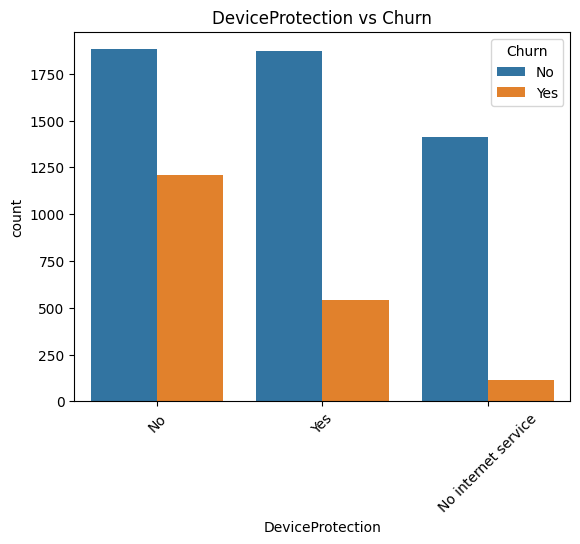

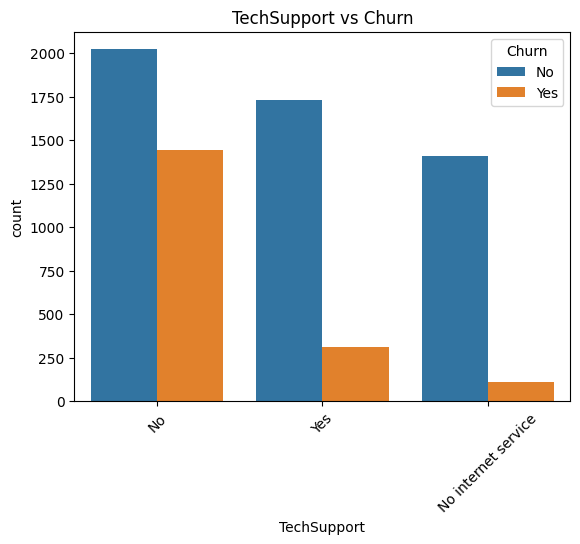

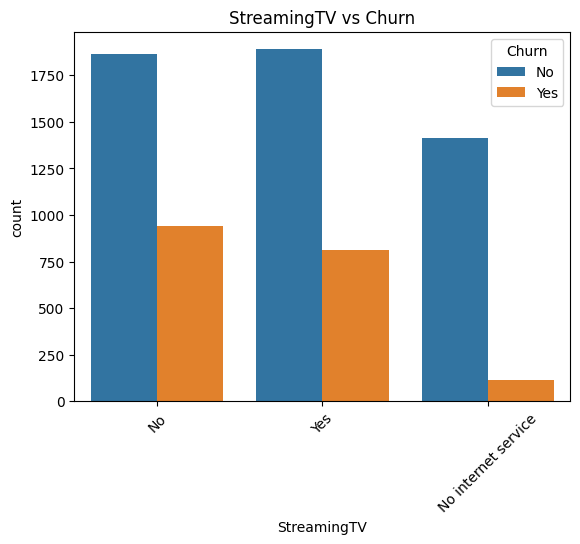

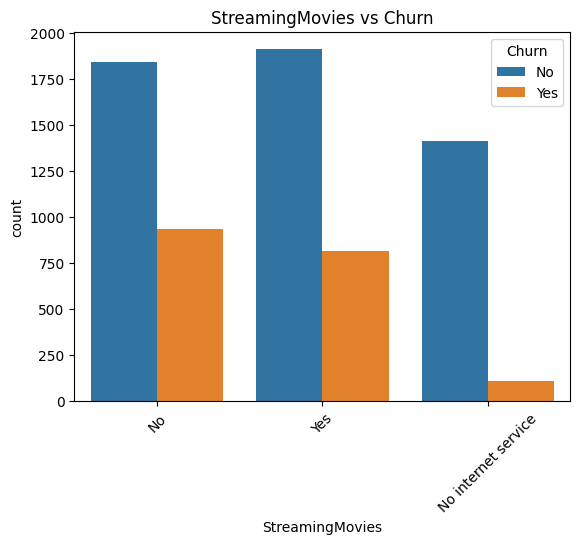

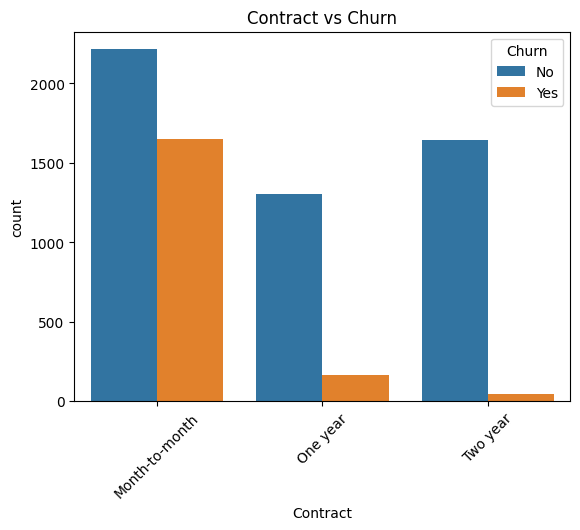

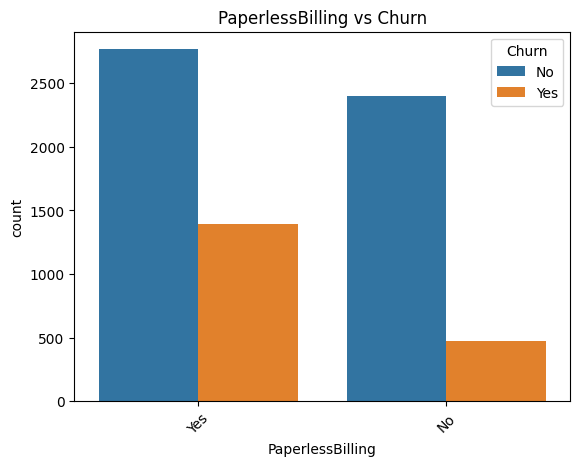

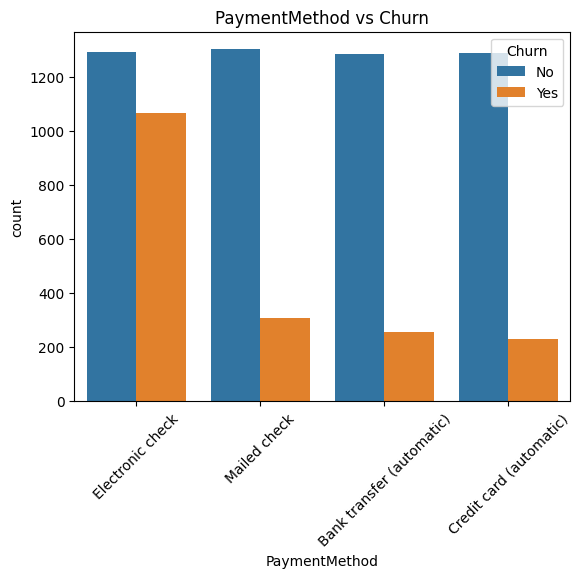

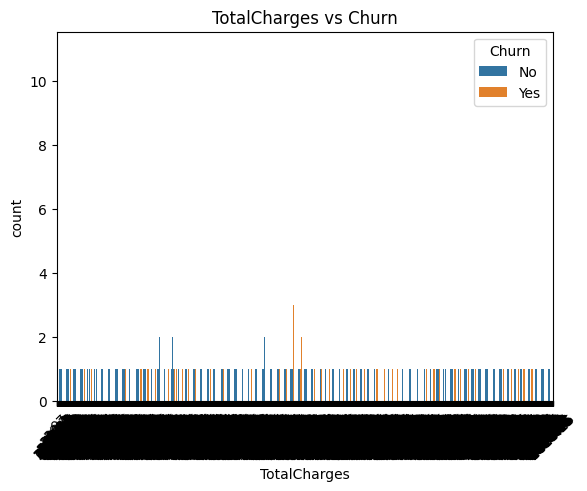

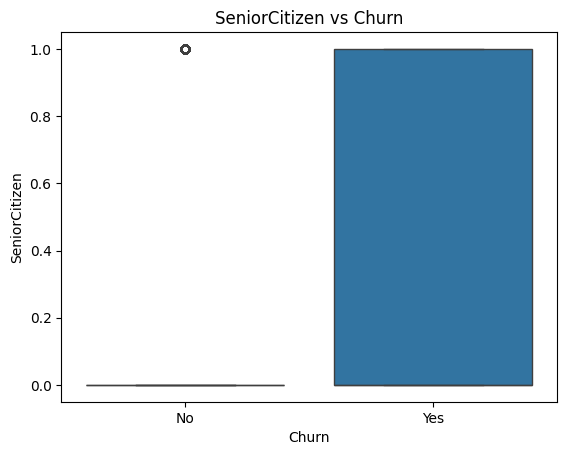

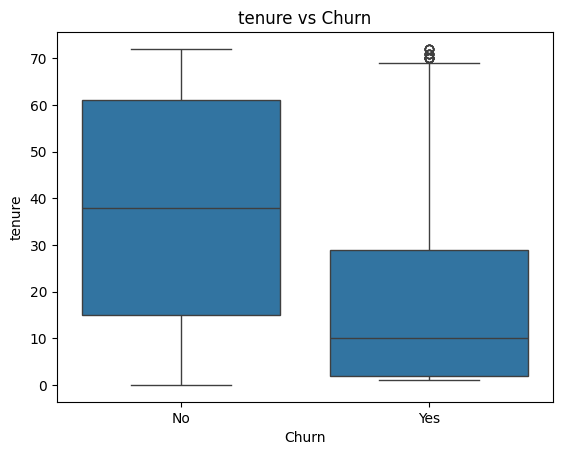

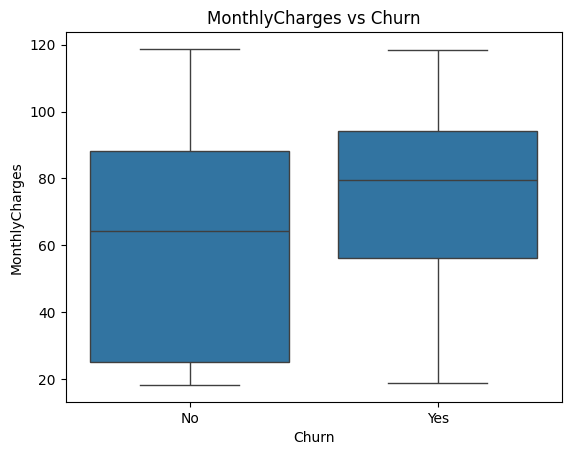

In [ ]:
# Task 7: Bivariate Analysis

# Categorical vs Churn
for col in cat_cols:
    if col != 'Churn':
        plt.figure()
        sns.countplot(x=col, hue='Churn', data=df)
        plt.xticks(rotation=45)
        plt.title(f"{col} vs Churn")
        plt.show()

# Numerical vs Churn
for col in num_cols:
    plt.figure()
    sns.boxplot(x='Churn', y=col, data=df)
    plt.title(f"{col} vs Churn")
    plt.show()

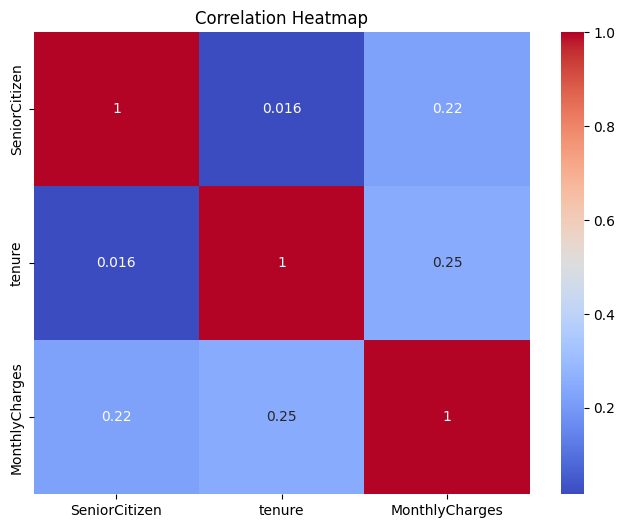

In [ ]:
# Task 8: Correlation Heatmap (FIXED)

# Select only numerical columns
numeric_df = df.select_dtypes(include=np.number)
plt.figure(figsize=(8,6))
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

In [ ]:
# Task 9: Outliers

print("Before:", df.shape)

Q1 = df[num_cols].quantile(0.25)
Q3 = df[num_cols].quantile(0.75)
IQR = Q3 - Q1

df = df[~((df[num_cols] < (Q1 - 1.5 * IQR)) | (df[num_cols] > (Q3 + 1.5 * IQR))).any(axis=1)]

print("After:", df.shape)

Before: (7031, 21)
After: (5890, 21)


In [ ]:
# Task 10: Encoding

# Label Encoding for target
le = LabelEncoder()
df['Churn'] = le.fit_transform(df['Churn'])  # Yes/No → 1/0

# One-Hot Encoding for categorical features
df = pd.get_dummies(df, drop_first=True)

print("Encoding Done")
print(df.head())

Encoding Done
   SeniorCitizen  tenure  MonthlyCharges  Churn  customerID_0003-MKNFE  \
0              0       1           29.85      0                  False   
1              0      34           56.95      0                  False   
2              0       2           53.85      1                  False   
3              0      45           42.30      0                  False   
8              0      28          104.80      1                  False   

   customerID_0004-TLHLJ  customerID_0013-MHZWF  customerID_0014-BMAQU  \
0                  False                  False                  False   
1                  False                  False                  False   
2                  False                  False                  False   
3                  False                  False                  False   
8                  False                  False                  False   

   customerID_0016-QLJIS  customerID_0017-DINOC  ...  TotalCharges_994.8  \
0                  F